# 13 · The ring lock, interactively

Companion to `run.py` / `README.md`. Every slider re-runs the **same** `ringlock.py` models (plant, Lorentzian sensor,
discrete PI with anti-windup, N-ring simulator, python-control design) that `run.py` uses, so nothing here is a separate approximation.

Sections:
1. **Sensor**: the notch, the photocurrent, the slope, and where δ_opt = FWHM/(2√3) comes from.
2. **Loop design**: T_d, crossover fraction ω_c·T_d, PI-zero placement, slow thermal share → Bode, margins, closed-loop step.
3. **Ambient step**: size, rise time, lock on/off → does the notch stay under the laser?
4. **Four rings**: crosstalk (nearest / next) and sweep rate while one ring acquires.
5. **Heater DAC bits and photocurrent noise**: steady-state jitter in pm.

Each section first draws a static figure for the default values (saved in the notebook, visible without a kernel) and then the same plot behind sliders; drag the sliders in JupyterLab to explore.

In [1]:
import sys, pathlib, json
HERE = pathlib.Path.cwd().resolve()
ROOT = HERE.parents[1]                       # experiments/13_capstone_ring_lock -> repo root
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(HERE))
from common import REF, use_style, SERIES, PALETTE
import numpy as np, control as ct
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown, Checkbox, FloatLogSlider
import ringlock as rl
%matplotlib inline
use_style(dpi=100)
pl, se = rl.Plant(), rl.Sensor()
D_OPT = se.delta_opt_pm; I_SET = float(se.I(D_OPT)); P0 = rl.nominal_heater_mw(pl, 60.0)
RES = json.loads((HERE / "out" / "results.json").read_text())
des = rl.design_pi(pl, se, t_d=10e-6)
assert abs(des["kp"] - RES["design"]["kp_mw_per_ua"]) < 1e-12, "notebook and run.py disagree on K_p"
print(f"δ_opt = {D_OPT:.2f} pm, I_set = {I_SET:.2f} µA, heater bias at 60 C = {P0:.2f} mW")
print(f"default design: K_p = {des['kp']:.5f} mW/µA, K_i = {des['ki']:.1f} mW/(µA·s), K_v = {des['Kv']:.0f} 1/s  (matches out/results.json)")

δ_opt = 107.96 pm, I_set = 29.62 µA, heater bias at 60 C = 7.89 mW
default design: K_p = 0.00387 mW/µA, K_i = 387.2 mW/(µA·s), K_v = 65827 1/s  (matches out/results.json)


## 1. The sensor: a Lorentzian notch read by one photodiode

T(δ) = 1 − (1 − T_min)/(1 + (2δ/FWHM)²), δ = λ_L − λ_r. The slope dT/dδ is largest at δ = FWHM/(2√3) and its sign flips at δ = 0:
a single photocurrent cannot tell the two sides apart, so the lock works only with the laser on the red side (δ > 0) and heating (which lowers δ).
Note how the sensor gain in µA/pm scales with P_in and 1/FWHM.

findfont: Failed to find font weight medium for DejaVu Sans, now using 400.


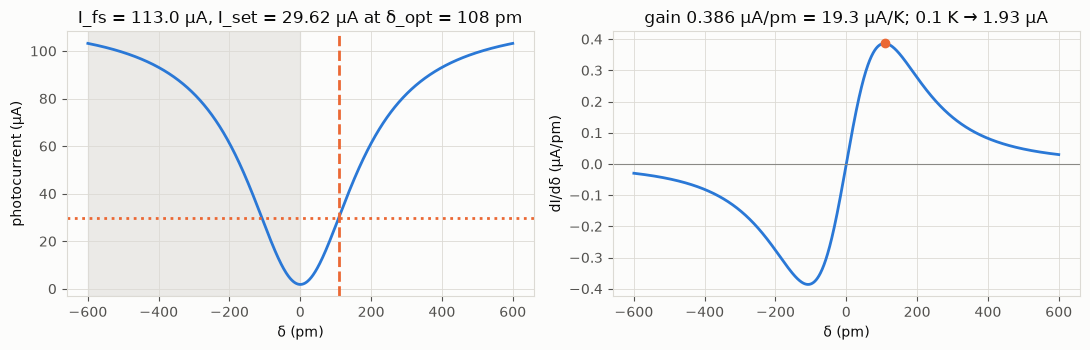

interactive(children=(FloatSlider(value=374.0, description='FWHM (pm)', max=1000.0, min=100.0, step=2.0), Floa…

In [2]:
def sensor_plot(fwhm_pm=374.0, t_min=0.016, p_in_dbm=4.0, tap_percent=5.0):
    s = rl.Sensor(fwhm_pm=fwhm_pm, t_min=t_min, p_in_mw=10 ** (p_in_dbm / 10), tap=tap_percent / 100)
    d = np.linspace(-600, 600, 1201); dopt = s.delta_opt_pm
    fig, axs = plt.subplots(1, 2, figsize=(11, 3.6))
    axs[0].plot(d, s.I(d), color=SERIES[0]); axs[0].axvline(dopt, color=SERIES[1], ls="--"); axs[0].axhline(s.I(dopt), color=SERIES[1], ls=":")
    axs[0].axvspan(-600, 0, color=PALETTE["line"], alpha=0.5); axs[0].set_xlabel("δ (pm)"); axs[0].set_ylabel("photocurrent (µA)")
    axs[0].set_title(f"I_fs = {s.i_fs_ua:.1f} µA, I_set = {s.I(dopt):.2f} µA at δ_opt = {dopt:.0f} pm")
    axs[1].plot(d, s.dI(d), color=SERIES[0]); axs[1].plot([dopt], [s.dI(dopt)], "o", color=SERIES[1]); axs[1].axhline(0, color=PALETTE["muted"], lw=0.8)
    axs[1].set_xlabel("δ (pm)"); axs[1].set_ylabel("dI/dδ (µA/pm)"); axs[1].set_title(f"gain {s.dI(dopt):.3f} µA/pm = {s.dI(dopt) * 50:.1f} µA/K; 0.1 K → {s.dI(dopt) * 5:.2f} µA")
    fig.tight_layout(); plt.show()
sensor_plot()   # static figure for the default values (kept in the saved notebook); the widget below is live
interact(sensor_plot, fwhm_pm=FloatSlider(374, min=100, max=1000, step=2, description="FWHM (pm)"),
         t_min=FloatSlider(0.016, min=0.0, max=0.5, step=0.004, description="T_min"),
         p_in_dbm=FloatSlider(4, min=-6, max=10, step=0.5, description="P_in (dBm)"),
         tap_percent=FloatSlider(5, min=1, max=20, step=0.5, description="tap (%)"));

## 2. Loop design with python-control

L(s) = C(s)·e^(−sT_d)·G_th(s)·(50 pm/K)·(dI/dδ). Tuning rule: PI zero cancels the fast thermal pole (or is placed elsewhere), K_p sets |L(jω_c)| = 1 at
ω_c = (crossover fraction)/T_d. The delay costs ω_c·T_d radians of phase at crossover: with the default 0.5 that is 28.6°, leaving PM ≈ 60°.
Try: crossover fraction 1.0 (PM ≈ 31°, ringing), T_d = 30 µs (crossover falls 3×, K_v falls 3×), slow share 0.5 (longer settling tail), zero at the slow pole (K_v ÷13).

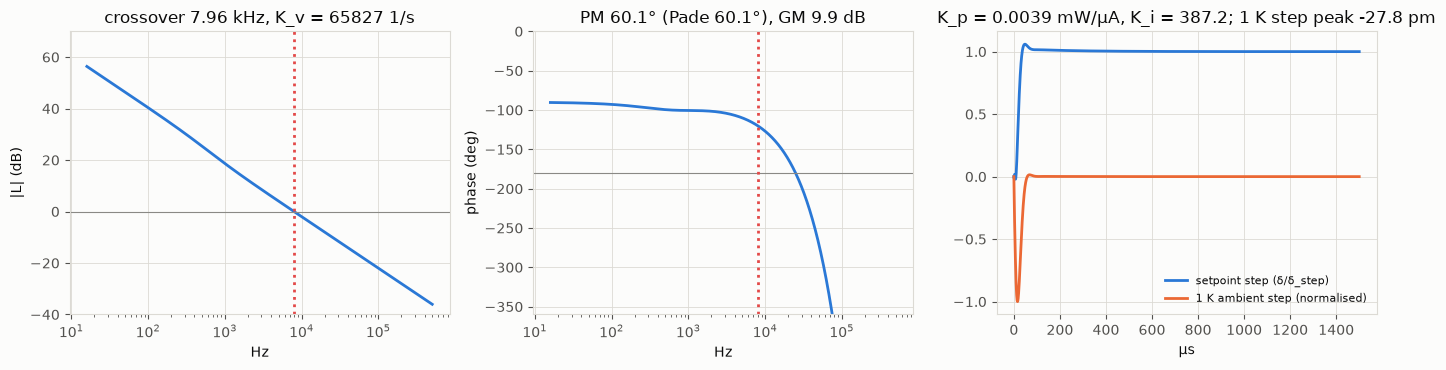

ramp 800 K/s tracking error = 0.61 pm;  M_s = 1.60


interactive(children=(FloatSlider(value=10.0, description='T_d (µs)', max=50.0, min=2.0, step=1.0), FloatSlide…

In [3]:
def design_plot(t_d_us=10.0, wc_times_td=0.5, zero_at="fast pole (10 µs)", slow_share=0.25, custom_tau_i_us=50.0):
    p = rl.Plant(slow_share=slow_share); t_d = t_d_us * 1e-6
    tau_i = {"fast pole (10 µs)": p.tau_fast, "slow pole (300 µs)": p.tau_slow, "custom": custom_tau_i_us * 1e-6}[zero_at]
    d = rl.design_pi(p, se, t_d=t_d, wc=wc_times_td / t_d, tau_i=tau_i)
    L, L0, C, PK = rl.loop_tf(p, se, d["kp"], d["ki"], t_d)
    gm, pm, wcg, wcp = ct.margin(L)
    w = np.logspace(2, 6.5, 3000); ex = rl.exact_margins(L0, t_d, w)
    Tcl = ct.feedback(L, 1); S = ct.feedback(1, L)
    tl = np.linspace(0, 1.5e-3, 3001); sr = ct.step_response(Tcl, tl)
    Gd = ct.minreal(-p.dlam_dT * p.thermal_tf(normalised=True) * S, verbose=False); dr = ct.forced_response(Gd, tl, np.ones_like(tl))
    fig, axs = plt.subplots(1, 3, figsize=(14, 3.8))
    axs[0].semilogx(w / 2 / np.pi, 20 * np.log10(ex["mag"]), color=SERIES[0]); axs[0].axhline(0, color=PALETTE["muted"], lw=0.8); axs[0].axvline(ex["wc"] / 2 / np.pi, color=SERIES[4], ls=":")
    axs[0].set_xlabel("Hz"); axs[0].set_ylabel("|L| (dB)"); axs[0].set_ylim(-40, 70); axs[0].set_title(f"crossover {ex['wc'] / 2 / np.pi / 1e3:.2f} kHz, K_v = {d['Kv']:.0f} 1/s")
    axs[1].semilogx(w / 2 / np.pi, ex["phase_deg"], color=SERIES[0]); axs[1].axhline(-180, color=PALETTE["muted"], lw=0.8); axs[1].axvline(ex["wc"] / 2 / np.pi, color=SERIES[4], ls=":")
    axs[1].set_ylim(-360, 0); axs[1].set_xlabel("Hz"); axs[1].set_ylabel("phase (deg)"); axs[1].set_title(f"PM {ex['pm_deg']:.1f}° (Pade {pm:.1f}°), GM {ex['gm_db']:.1f} dB")
    axs[2].plot(tl * 1e6, sr.outputs, color=SERIES[0], label="setpoint step (δ/δ_step)"); axs[2].plot(tl * 1e6, dr.outputs / abs(dr.outputs.min()), color=SERIES[1], label="1 K ambient step (normalised)")
    axs[2].set_xlabel("µs"); axs[2].set_title(f"K_p = {d['kp']:.4f} mW/µA, K_i = {d['ki']:.1f}; 1 K step peak {dr.outputs.min():.1f} pm"); axs[2].legend(fontsize=8)
    fig.tight_layout(); plt.show()
    print(f"ramp 800 K/s tracking error = {800 * 50 / d['Kv']:.2f} pm;  M_s = {ct.frequency_response(S, w).magnitude.max():.2f}")
design_plot()   # static figure for the default values (kept in the saved notebook); the widget below is live
interact(design_plot, t_d_us=FloatSlider(10, min=2, max=50, step=1, description="T_d (µs)"),
         wc_times_td=FloatSlider(0.5, min=0.1, max=1.2, step=0.05, description="ω_c·T_d"),
         zero_at=Dropdown(options=["fast pole (10 µs)", "slow pole (300 µs)", "custom"], value="fast pole (10 µs)", description="PI zero"),
         slow_share=FloatSlider(0.25, min=0.0, max=0.6, step=0.05, description="slow share"),
         custom_tau_i_us=FloatLogSlider(50, base=10, min=0.5, max=3, step=0.05, description="τ_i custom (µs)"));

## 3. Ambient step: does the notch stay under the laser?

The ambient deviation enters the ring through its own thermal filter (75 % in 10 µs). The lock survives an *instantaneous* step only up to ~6 K because the notch
bottom must not pass the laser (below δ = 0 the sensor slope reverses); give the step a 100 µs rise and even 15 K is fine. Untick the lock to watch the notch drift away.

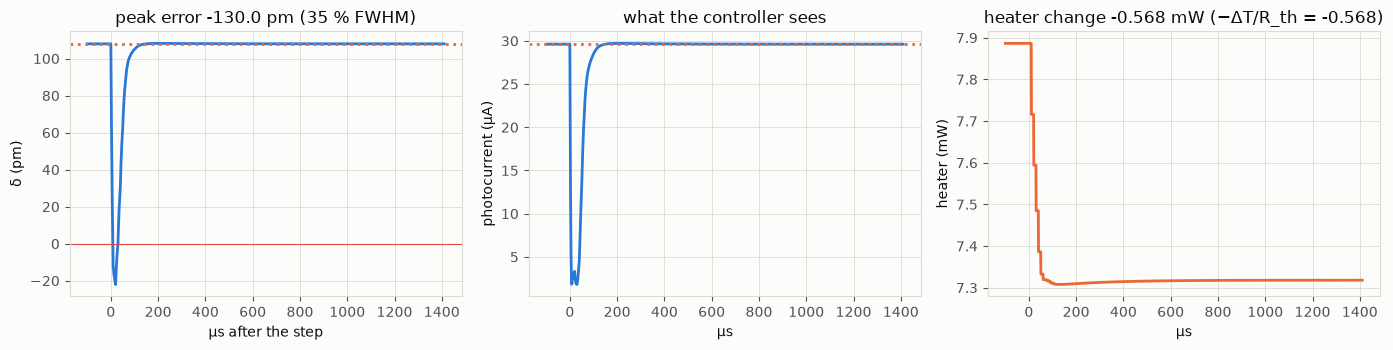

final error +0.002 pm -> LOCKED


interactive(children=(FloatSlider(value=5.0, description='step (K)', max=20.0, min=0.5, step=0.5), FloatSlider…

In [4]:
def step_plot(step_K=5.0, rise_us=0.0, lock_on=True, t_d_us=10.0, wc_times_td=0.5):
    t_d = t_d_us * 1e-6; d = rl.design_pi(pl, se, t_d=t_d, wc=wc_times_td / t_d)
    ts = t_d
    c = rl.PIController(kp=d["kp"], ki=d["ki"], i_set=I_SET, ts=ts, p_init=P0)
    T0 = 100e-6
    amb = (lambda t: np.array([step_K if t >= T0 else 0.0])) if rise_us <= 0 else (lambda t: np.array([step_K * (1 - np.exp(-(t - T0) / (rise_us * 1e-6))) if t >= T0 else 0.0]))
    r = rl.simulate(pl, se, [c], 1.5e-3 + 4 * rise_us * 1e-6, ambient_fn=amb, p_nominal_mw=P0, lock_enabled=[lock_on])
    e = r.delta[:, 0] - D_OPT
    fig, axs = plt.subplots(1, 3, figsize=(14, 3.6))
    axs[0].plot((r.t - T0) * 1e6, r.delta[:, 0], color=SERIES[0]); axs[0].axhline(D_OPT, color=SERIES[1], ls=":"); axs[0].axhline(0, color=SERIES[4], lw=0.8)
    axs[0].set_xlabel("µs after the step"); axs[0].set_ylabel("δ (pm)"); axs[0].set_title(f"peak error {e[np.argmax(np.abs(e))]:+.1f} pm ({100 * abs(e).max() / se.fwhm_pm:.0f} % FWHM)")
    axs[1].plot((r.t - T0) * 1e6, r.i[:, 0], color=SERIES[0]); axs[1].axhline(I_SET, color=SERIES[1], ls=":"); axs[1].set_xlabel("µs"); axs[1].set_ylabel("photocurrent (µA)"); axs[1].set_title("what the controller sees")
    axs[2].plot((r.t - T0) * 1e6, r.p[:, 0], color=SERIES[1]); axs[2].set_xlabel("µs"); axs[2].set_ylabel("heater (mW)"); axs[2].set_title(f"heater change {r.p[-1, 0] - P0:+.3f} mW (−ΔT/R_th = {-step_K / pl.r_th:+.3f})")
    fig.tight_layout(); plt.show()
    final = e[-200:].mean(); print(f"final error {final:+.3f} pm -> " + ("LOCKED" if abs(final) < 2 else "LOCK LOST (wrong side of the notch or heater rail)"))
step_plot()   # static figure for the default values (kept in the saved notebook); the widget below is live
interact(step_plot, step_K=FloatSlider(5, min=0.5, max=20, step=0.5, description="step (K)"),
         rise_us=FloatSlider(0, min=0, max=500, step=10, description="extra rise (µs)"),
         lock_on=Checkbox(True, description="lock on"),
         t_d_us=FloatSlider(10, min=2, max=50, step=1, description="T_d = T_s (µs)"),
         wc_times_td=FloatSlider(0.5, min=0.1, max=1.2, step=0.05, description="ω_c·T_d"));

## 4. Four rings sharing a substrate

Ring 3 starts cold (heater 0) and sweeps its heater up at the chosen rate until its photocurrent drops below I(δ = 300 pm), then hands over to the PI.
Its neighbours are heated by K_ij·P_3 and must back off their own heaters. During the sweep the neighbours see a ramp disturbance,
so their error is (K_ij × sweep rate × 440 pm/mW)/K_v; the sharp spike at capture is ring 3's own PI transient. Increase the crosstalk to see the coupled equilibrium K⁻¹·P0·1.

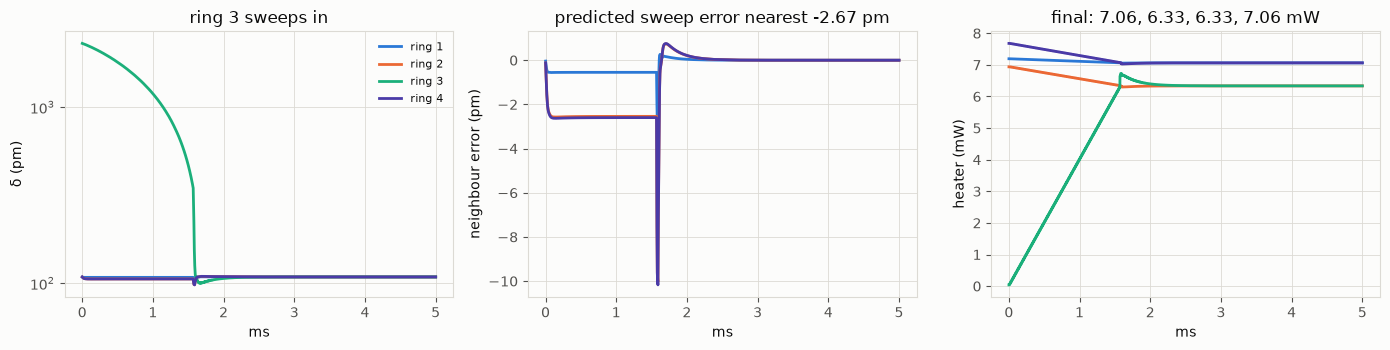

K⁻¹·P0·1 = [7.063 6.335 6.335 7.063]  mW;  crosstalk heating of ring 2 by ring 3: 5.57 K


interactive(children=(FloatSlider(value=0.1, description='K nearest', max=0.4, step=0.01), FloatSlider(value=0…

In [5]:
def four_ring_plot(k_nearest=0.10, k_next=0.03, sweep_mw_per_ms=4.0):
    N = 4; K = rl.crosstalk_matrix(N, k_nearest, k_next); ACQ = 2
    d = rl.design_pi(pl, se, t_d=10e-6)
    S_idx = [i for i in range(N) if i != ACQ]
    p_init = np.zeros(N); p_init[S_idx] = np.linalg.solve(K[np.ix_(S_idx, S_idx)], np.full(3, P0))
    ctrls = [rl.PIController(kp=d["kp"], ki=d["ki"], i_set=I_SET, p_init=float(p_init[i]), acquire=(i == ACQ), i_capture=float(se.I(300.0)), sweep_rate=sweep_mw_per_ms * 1e3) for i in range(N)]
    r = rl.simulate(pl, se, ctrls, 3e-3 + 8.0 / sweep_mw_per_ms * 1e-3, K=K, p_nominal_mw=P0)
    fig, axs = plt.subplots(1, 3, figsize=(14, 3.6))
    for i in range(N):
        axs[0].plot(r.t * 1e3, r.delta[:, i], color=SERIES[i], label=f"ring {i + 1}")
        if i != ACQ: axs[1].plot(r.t * 1e3, r.delta[:, i] - D_OPT, color=SERIES[i])
        axs[2].plot(r.t * 1e3, r.p[:, i], color=SERIES[i])
    axs[0].set_yscale("symlog", linthresh=200); axs[0].set_xlabel("ms"); axs[0].set_ylabel("δ (pm)"); axs[0].legend(fontsize=8); axs[0].set_title("ring 3 sweeps in")
    axs[1].set_xlabel("ms"); axs[1].set_ylabel("neighbour error (pm)"); axs[1].set_title(f"predicted sweep error nearest {-k_nearest * sweep_mw_per_ms * 1e3 * pl.heater_pm_per_mw / d['Kv']:+.2f} pm")
    axs[2].set_xlabel("ms"); axs[2].set_ylabel("heater (mW)"); axs[2].set_title("final: " + ", ".join(f"{x:.2f}" for x in r.p[-1]) + " mW")
    fig.tight_layout(); plt.show()
    print("K⁻¹·P0·1 =", np.round(np.linalg.solve(K, np.full(N, P0)), 3), " mW;  crosstalk heating of ring 2 by ring 3:", f"{k_nearest * r.p[-1, ACQ] * pl.r_th:.2f} K")
four_ring_plot()   # static figure for the default values (kept in the saved notebook); the widget below is live
interact(four_ring_plot, k_nearest=FloatSlider(0.10, min=0, max=0.4, step=0.01, description="K nearest"),
         k_next=FloatSlider(0.03, min=0, max=0.2, step=0.01, description="K next"),
         sweep_mw_per_ms=FloatSlider(4, min=0.5, max=20, step=0.5, description="sweep (mW/ms)"));

## 5. Heater DAC resolution and photocurrent noise

An 8-bit DAC over 20 mW is 78 µW = 34 pm per step: the loop can only dither between two steps. 12 bits (2 pm) is enough for the 5 pm (0.1 K) question.
Photocurrent noise is a non-issue: even 50 nA rms per 10 µs sample (70× the shot noise) is 0.13 pm input-referred.

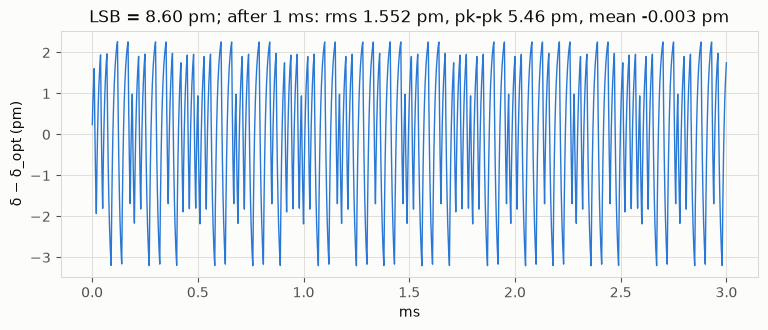

interactive(children=(IntSlider(value=10, description='DAC bits (16 = ideal)', max=16, min=6), FloatSlider(val…

In [6]:
def quant_plot(dac_bits=10, i_noise_na=0.0, p_max_mw=20.0):
    d = rl.design_pi(pl, se, t_d=10e-6)
    c = rl.PIController(kp=d["kp"], ki=d["ki"], i_set=I_SET, p_init=P0, p_max=p_max_mw, dac_bits=(None if dac_bits >= 16 else dac_bits))
    r = rl.simulate(pl, se, [c], 3e-3, p_nominal_mw=P0, i_noise_ua=i_noise_na * 1e-3, seed=1)
    e = r.delta[:, 0] - D_OPT; e2 = e[int(1e-3 / 1e-6):]
    fig, ax = plt.subplots(figsize=(9, 3.2)); ax.plot(r.t * 1e3, e, color=SERIES[0], lw=1); ax.set_xlabel("ms"); ax.set_ylabel("δ − δ_opt (pm)")
    lsb = (p_max_mw / (2 ** dac_bits - 1)) * pl.heater_pm_per_mw if dac_bits < 16 else 0
    ax.set_title(f"LSB = {lsb:.2f} pm; after 1 ms: rms {e2.std():.3f} pm, pk-pk {e2.max() - e2.min():.2f} pm, mean {e2.mean():+.3f} pm"); plt.show()
quant_plot()   # static figure for the default values (kept in the saved notebook); the widget below is live
interact(quant_plot, dac_bits=IntSlider(10, min=6, max=16, step=1, description="DAC bits (16 = ideal)"),
         i_noise_na=FloatSlider(0, min=0, max=500, step=10, description="I noise (nA rms)"),
         p_max_mw=FloatSlider(20, min=10, max=50, step=1, description="P_max (mW)"));